## **Image Question Answering with Shapes [10pts + 2 extra]**

### **0. Loading resources and installing extra libraries**

In [18]:
# !python3 -m venv env; source env/bin/activate
!pip install -q livelossplot 
![ -f ShapesQA_trainset.zip ] || curl -sLO https://www.cs.rice.edu/~vo9/deep-vislang/ShapesQA_trainset.zip
!unzip -qn ShapesQA_trainset.zip
![ -d ShapesQA_trainset ] || mv synthetic_shapes_dataset ShapesQA_trainset
![ -f ShapesQA_valset.zip ] || curl -sLO https://www.cs.rice.edu/~vo9/deep-vislang/ShapesQA_valset.zip
!unzip -qn ShapesQA_valset.zip
![ -d ShapesQA_valset ] || mv synthetic_shapes_dataset ShapesQA_valset
!pip install torch torchvision transformers 


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### **1. Defining a Dataset class**

For this assignment we have created a novel dataset called ShapesQA which is a question answering dataset about images with simple geometric shapes consisting of triangles, circles and squares. The goal is to build a model that can answer questions for this dataset using all the tools at our disposal including for representing images and text.

In [8]:
import torch, json, random, os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

class ShapesQADataset(Dataset):
    def __init__(self, annotations = "",
                 image_dir = "", vocab = None,
                 transform = None,
                 max_question_len = 20):
        self.annotations = json.load(open(annotations))
        self.image_dir = image_dir
        self.vocab = vocab
        self.transform = transform if transform is not None else transforms.ToTensor()
        self.max_question_len = max_question_len
        # Define a fixed answer mapping (example: 6 colors, 3 shapes, 6 counts = 15 classes)
        self.answer2idx = {"red": 0, "blue": 1, "green": 2, "yellow": 3, "purple": 4, "orange": 5,
                      "circle": 6, "square": 7, "triangle": 8,
                      "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14}
        self.idx2answer = {v: k for k, v in self.answer2idx.items()}

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        image_path = os.path.join(self.image_dir, ann["image"])
        image = Image.open(image_path).convert("RGB")

        # Apply image transformation if specified.
        if self.transform:
            image = self.transform(image)

        question = ann["question"]
        # Apply tokenization to input question if specified.
        if self.vocab:
          tokens = tokenize(question)
          indices = [self.vocab.get(token, self.vocab["<unk>"]) for token in tokens]
          if len(indices) < self.max_question_len:
              indices = indices + [self.vocab["<pad>"]] * (self.max_question_len - len(indices))
          else:
              indices = indices[:self.max_question_len]
          question = torch.tensor(indices, dtype=torch.long)
        answer = str(ann["answer"])
        label = self.answer2idx.get(answer, 0)
        label = torch.tensor(label, dtype=torch.long)

        return {"image": image, "question": question, "answer": label, "question_type": ann["question_type"]}

trainset = ShapesQADataset(annotations="ShapesQA_trainset/annotations.json",
                           vocab = None,
                           image_dir="ShapesQA_trainset")
valset = ShapesQADataset(annotations="ShapesQA_valset/annotations.json",
                         vocab = None,
                         image_dir="ShapesQA_valset")

print("Num training images: ", len(trainset))
print("Num validation images: ", len(valset))

Num training images:  1000
Num validation images:  1000


Now let's show a random example from this dataset. Look at many examples by running this code several times to get an idea of the difficulty of the problem.

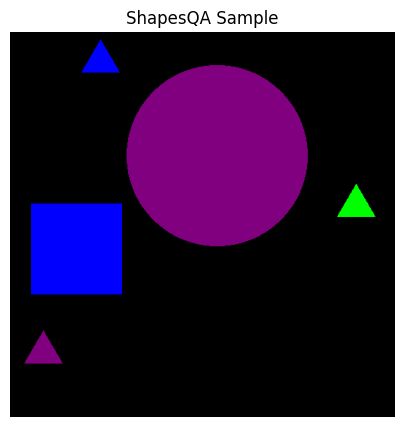

Question: Identify the color of the largest square in the picture.
Answer: blue
Question type: extreme


In [9]:
def show_sample(sample):
    image_tensor = sample["image"]
    image_np = image_tensor.permute(1, 2, 0).numpy()
    plt.figure(figsize=(5,5))
    plt.imshow(image_np); plt.axis("off")
    plt.title("ShapesQA Sample"); plt.show()
    print("Question:", sample["question"])
    print("Answer:", trainset.idx2answer[sample["answer"].item()])
    print("Question type:", sample["question_type"])

# Display a random sample.
sample_idx = random.randint(0, len(valset) - 1)
sample = valset[sample_idx]
show_sample(sample)

### **2. Defining how batches are loaded**

Here we define how data samples are going to be converted to batch tensors when creating a data loader. Another common step in setting up our problem. In this case, text input needs to be handled such that they can be put in batches despite different questions having different lengths in terms of number of words. A common strategy is to tokenize the input, convert to numerical ids for every word by creating a dictionary (vocabulary) and then using special tokens for words outside the vocabulary and for padding the texts so they all end up with the same length in a batch.

In [10]:
from collections import Counter

def tokenize(text):
    # A simple tokenizer: lowercase and split on whitespace.
    return text.lower().split()

def build_vocab(questions, min_freq=1):
    """Builds a word2idx dictionary from a list of question strings."""
    counter = Counter()
    for q in questions:
        tokens = tokenize(q)
        counter.update(tokens)
    # Reserve index 0 for <pad> and 1 for <unk>
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# The collate_fn is a special function in pytorch to indicate how batches
# should be assembled.
def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    questions = torch.stack([item["question"] for item in batch], dim=0)
    answers = torch.stack([item["answer"] for item in batch], dim=0)
    # Collect question types as a list of strings.
    question_types = [item["question_type"] for item in batch]
    return {"image": images, "question": questions, "answer": answers, "question_type": question_types}


train_annotations = json.load(open("ShapesQA_trainset/annotations.json"))
all_train_questions = [ann["question"] for ann in train_annotations]
vocab = build_vocab(all_train_questions, min_freq=1)
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

# Sample code for loading one batch.
trainset = ShapesQADataset(annotations="ShapesQA_trainset/annotations.json",
                           vocab = vocab,
                           image_dir="ShapesQA_trainset")
train_loader = DataLoader(trainset, batch_size=32, shuffle=True, collate_fn=collate_fn)
for batch in train_loader:
    images = batch["image"]
    questions = batch["question"]
    answers = batch["answer"]
    question_types = batch["question_type"]
    print("Image batch shape:", images.shape)
    print("Question batch shape:", questions.shape)
    print("Answer batch shape:", answers.shape)
    print("Question type shape:", question_types)
    break


Vocabulary size: 62
Image batch shape: torch.Size([32, 3, 512, 512])
Question batch shape: torch.Size([32, 20])
Answer batch shape: torch.Size([32])
Question type shape: ['count', 'count', 'extreme', 'extreme', 'extreme', 'count', 'count', 'left_right', 'extreme', 'extreme', 'unique', 'unique', 'unique', 'unique', 'extreme', 'count', 'extreme', 'extreme', 'count', 'count', 'unique', 'extreme', 'extreme', 'count', 'unique', 'unique', 'unique', 'left_right', 'unique', 'unique', 'unique', 'count']


### **3. Defining a model to solve this problem [1pt]**

Create a model to solve this problem. This model takes as input a batch of texts (questions) and images, and outputs an answer.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

class VQAModel(nn.Module):
    # Feel free to add/adjust parameters here as needed.
    def __init__(self, vocab_size, num_answers, word_dim=128, text_hidden=128, fusion_dim=256, dropout=0.30):
        super(VQAModel, self).__init__()
        # Initialize the layers for your model.
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        cnn_feat_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # Freeze CNN branch first; training loop later unfreezes it.
        for param in self.cnn.parameters():
            param.requires_grad = False

        self.embedding = nn.Embedding(vocab_size, word_dim, padding_idx=0)
        self.text_encoder = nn.GRU(
            input_size=word_dim,
            hidden_size=text_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.image_proj = nn.Sequential(
            nn.Linear(cnn_feat_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_hidden * 2, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_answers),
        )

    def forward(self, images, questions):
        # Return the appropriate output here to answer questions.
        image_feat = self.cnn(images)  # (B, cnn_feat_dim)

        question_emb = self.embedding(questions)  # (B, L, word_dim)
        _, h_n = self.text_encoder(question_emb)  # h_n: (2, B, text_hidden)
        question_feat = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (B, 2*text_hidden)

        fused = torch.cat([
            self.image_proj(image_feat),
            self.text_proj(question_feat)
        ], dim=1)

        logits = self.classifier(fused)
        return logits


# Example usage using a random dummy input.
vocab_size = 1000
num_answers = 15  # e.g., 6 colors + 3 shapes + 6 count answers
model = VQAModel(vocab_size, num_answers)
images = torch.randn(32, 3, 256, 256)  # (batch, channels, height, width)
questions = torch.randint(0, vocab_size, (32, 20))
logits = model(images, questions)
print("Output shape:", logits.shape)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/apple/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Output shape: torch.Size([32, 15])


### **4. Training Loop [2pt]**

This is the standard training loop. One requirement is that you need to use at least two forms of data augmentation. The required accuracy for this part is at minimum 40% overall accuracy across all types of questions. The result from this section and the next have to be reported in this [spreadsheet](https://docs.google.com/spreadsheets/d/1vIinHGtzcPIOKHvZAo_Jgh0JYHlkff98LjBfzDs514k/edit?usp=sharing).

In [12]:
# ============================================================
# Create Vocabulary for the tokenizer.
# ============================================================
train_annotations_file = "ShapesQA_trainset/annotations.json"
val_annotations_file   = "ShapesQA_valset/annotations.json"
train_image_dir = "ShapesQA_trainset"
val_image_dir   = "ShapesQA_valset"

with open(train_annotations_file, "r") as f:
    train_annotations = json.load(f)
with open(val_annotations_file, "r") as f:
    val_annotations = json.load(f)

all_train_questions = [ann["question"] for ann in train_annotations]
vocab = build_vocab(all_train_questions, min_freq=1)
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

# ============================================================
# Create Datasets and DataLoaders
# ============================================================
# You are required to make some changes here as specified earlier.
train_image_transform = transforms.Compose([
    transforms.ToTensor()#,
])
image_transform = transforms.Compose([
    transforms.ToTensor()#,
])

train_dataset = ShapesQADataset(annotations=train_annotations_file,
                           image_dir=train_image_dir,
                           vocab=vocab,
                           transform=train_image_transform,
                           max_question_len=20)
val_dataset = ShapesQADataset(annotations=val_annotations_file,
                         image_dir=val_image_dir,
                         vocab=vocab,
                         transform=image_transform,
                         max_question_len=20)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

# ============================================================
# Initialize Model, Loss, and Optimizer
# ============================================================

num_answers = 15  # e.g., 6 colors + 3 shapes + 6 count answers
model = VQAModel(vocab_size, num_answers=num_answers)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Feel free to change this to whatever you consider most appropriate.
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# ============================================================
# Training and Validation Loops with Livelossplot
# ============================================================
# NOTE: Feel free to modify any of the code below. This is just what worked
# for me with the model I created.

from livelossplot import PlotLosses

liveplot = PlotLosses()
# Feel free to change any hyperparameters here.
num_epochs = 30  # Total epochs

# Define the epoch at which to unfreeze the CNN branch.
freeze_epochs = 20 # Freeze for the first 18 epochs, unfreeze for the last 2 epochs

def train_model(model, optimizer, train_loader, val_loader, num_epochs, freeze_epochs):

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        # Unfreeze CNN parameters at the start of epoch freeze_epochs.
        if epoch == freeze_epochs:
            print("Unfreezing CNN parameters for fine-tuning...")
            for param in model.cnn.parameters():
                param.requires_grad = True
            # Update the optimizer to include the newly unfrozen CNN parameters.
            optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_loader:
            images = batch["image"].to(device)         # (batch, 3, H, W)
            questions = batch["question"].to(device)     # (batch, max_question_len)
            answers = batch["answer"].to(device)         # (batch,)

            optimizer.zero_grad()
            logits = model(images, questions)            # (batch, num_answers)
            loss = criterion(logits, answers)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == answers).sum().item()
            total_train += answers.size(0)

        avg_train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                questions = batch["question"].to(device)
                answers = batch["answer"].to(device)

                logits = model(images, questions)
                loss = criterion(logits, answers)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == answers).sum().item()
                total_val += answers.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

        liveplot.update({
            'loss': avg_train_loss,
            'accuracy': train_acc,
            'val_loss': avg_val_loss,
            'val_accuracy': val_acc,
        })
        liveplot.send()

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
            f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

    model.load_state_dict(best_model_state)
    return model

Vocabulary size: 62


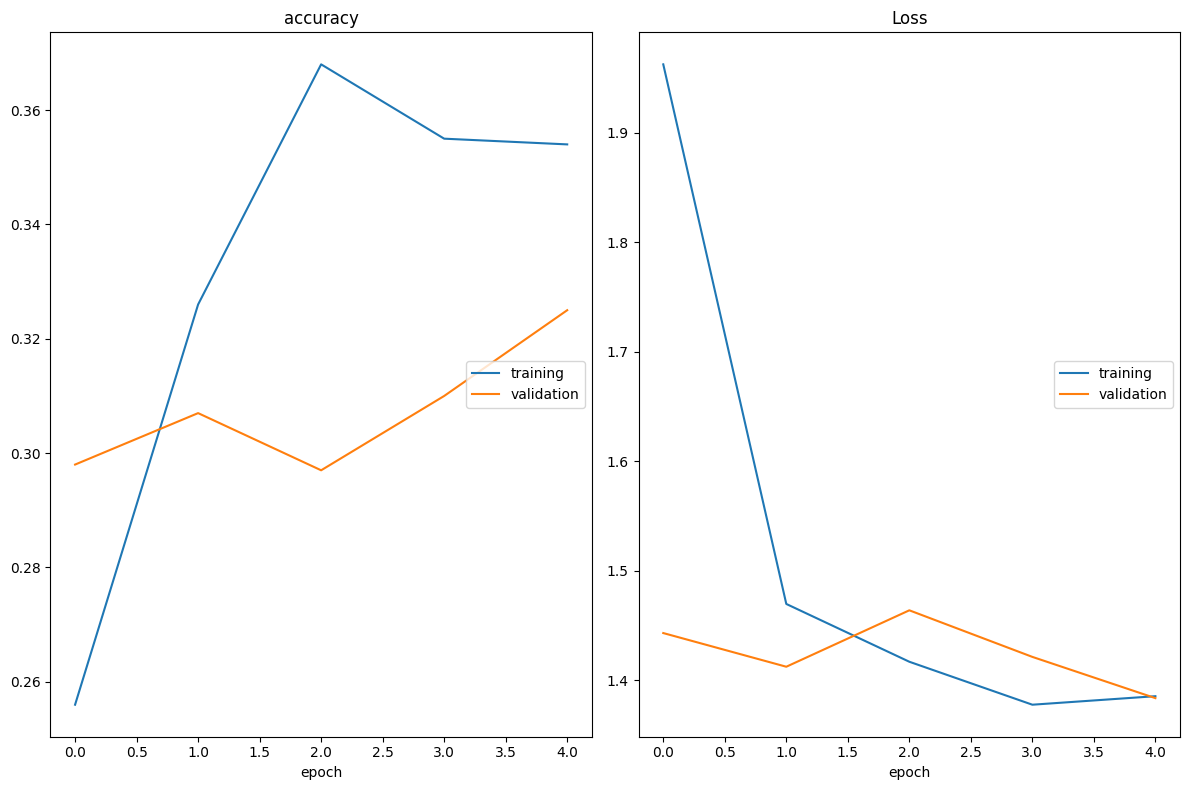

accuracy
	training         	 (min:    0.256, max:    0.368, cur:    0.354)
	validation       	 (min:    0.297, max:    0.325, cur:    0.325)
Loss
	training         	 (min:    1.378, max:    1.962, cur:    1.386)
	validation       	 (min:    1.384, max:    1.464, cur:    1.384)
Epoch 5/30: Train Loss = 1.3857, Train Acc = 0.3540, Val Loss = 1.3839, Val Acc = 0.3250


KeyboardInterrupt: 

In [13]:
model = train_model(model, optimizer, train_loader, val_loader, num_epochs, freeze_epochs)

### **5. Further Evaluating this model**

Let's evaluate the model again but now let's breakdown its performance by type of question. Report your results in this [spreadsheet](https://docs.google.com/spreadsheets/d/1vIinHGtzcPIOKHvZAo_Jgh0JYHlkff98LjBfzDs514k/edit?usp=sharing):

In [ ]:
# --- Compute accuracy per question type on the validation set ---
model.eval()
type_correct = {}  # Dictionary to count correct predictions per type.
type_total = {}    # Dictionary to count total samples per type.

with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(device)
        questions = batch["question"].to(device)
        answers = batch["answer"].to(device)
        q_types = batch["question_type"]  # List of question type strings for this batch

        logits = model(images, questions)  # (batch, num_answers)
        preds = torch.argmax(logits, dim=1)  # (batch,)

        # Loop over each sample in the batch.
        for i, qt in enumerate(q_types):
            if qt not in type_total:
                type_total[qt] = 0
                type_correct[qt] = 0
            type_total[qt] += 1
            if preds[i] == answers[i]:
                type_correct[qt] += 1

print("\nValidation Accuracy per Question Type:")
for qt in type_total:
    accuracy = type_correct[qt] / type_total[qt]
    print(f"  Question type '{qt}': Accuracy = {accuracy:.4f} ({type_correct[qt]}/{type_total[qt]})")


Validation Accuracy per Question Type:
  Question type 'count': Accuracy = 0.3533 (112/317)
  Question type 'extreme': Accuracy = 0.3278 (99/302)
  Question type 'unique': Accuracy = 0.5149 (173/336)
  Question type 'left_right': Accuracy = 0.3778 (17/45)


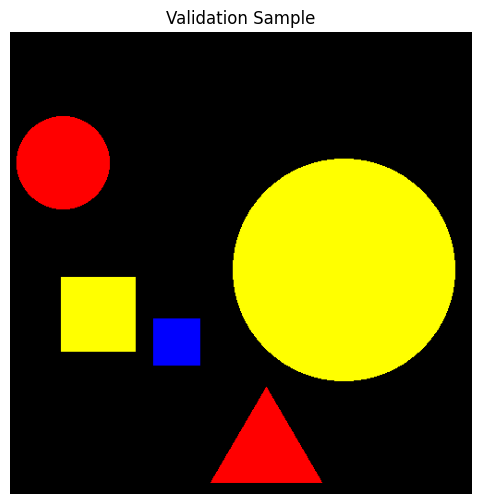

Original Question:
Count the number of purple objects in the picture.

Ground Truth Answer:
0

Predicted Answer:
1


In [ ]:
# ============================================================
#  Display a Sample Prediction from Validation Set
# ============================================================

# Define the answer mapping (same as used in your dataset)
answer2idx = {
    "red": 0, "blue": 1, "green": 2, "yellow": 3, "purple": 4, "orange": 5,
    "circle": 6, "square": 7, "triangle": 8,
    "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14
}
idx2answer = {v: k for k, v in answer2idx.items()}

# --- Display a sample prediction from the validation set ---

# Pick a random index from the validation dataset
val_idx = random.randint(0, len(val_dataset) - 1)
sample = val_dataset[val_idx]  # sample from the custom Dataset; contains tokenized question, image, label
val_annotations = json.load(open(val_annotations_file))

# Retrieve the original annotation for the chosen sample
original_ann = val_annotations[val_idx]
original_question = original_ann["question"]
ground_truth_answer = str(original_ann["answer"])

# Prepare the sample for model prediction (add batch dimension)
model.eval()
image = sample["image"].unsqueeze(0).to(device)        # shape: (1, 3, H, W)
question = sample["question"].unsqueeze(0).to(device)    # shape: (1, max_question_len)
with torch.no_grad():
    logits = model(image, question)                      # shape: (1, num_answers)
    pred_idx = torch.argmax(logits, dim=1).item()
predicted_answer = idx2answer[pred_idx]

# Display the image
sample_img = image[0].cpu().permute(1, 2, 0).numpy()
plt.figure(figsize=(6,6))
plt.imshow(sample_img)
plt.axis("off")
plt.title("Validation Sample")
plt.show()

# Print the original question, ground truth answer, and predicted answer
print("Original Question:")
print(original_question)
print("\nGround Truth Answer:")
print(ground_truth_answer)
print("\nPredicted Answer:")
print(predicted_answer)

## **Assignment Questions**

#### **1. Random Guesser Accuracy [0.5pts]**
What is the accuracy of a model that takes a random guess to provide an answer and ignores the input question and input image? Show your calculation in the cell below.

In [14]:
# Random guesser baseline: uniform random guess over 15 answer classes.

num_answer_classes = len(train_dataset.answer2idx)
random_guesser_theoretical = 1.0 / num_answer_classes

# Optional empirical estimate on validation labels.
val_answer_indices = [train_dataset.answer2idx[str(ann["answer"])] for ann in val_annotations]
val_answer_indices = np.array(val_answer_indices)
rng = np.random.default_rng(42)
random_preds = rng.integers(low=0, high=num_answer_classes, size=len(val_answer_indices))
random_guesser_empirical = (random_preds == val_answer_indices).mean()

print(f"Number of answer classes: {num_answer_classes}")
print(f"Theoretical random-guess accuracy = 1/{num_answer_classes} = {random_guesser_theoretical:.4f} ({100*random_guesser_theoretical:.2f}%)")
print(f"Empirical single-run estimate on val set = {random_guesser_empirical:.4f} ({100*random_guesser_empirical:.2f}%)")


Number of answer classes: 15
Theoretical random-guess accuracy = 1/15 = 0.0667 (6.67%)
Empirical single-run estimate on val set = 0.0700 (7.00%)


#### **2. Zero-knowledge Accuracy [0.5pts]**
What is the accuracy of a model that guesses but takes advantage of the probability distribution of answers in the training set. Show your calculation in the cell below.

In [15]:
# Zero-knowledge guesser baseline:
# Guess according to p_train(answer), ignoring image/question.

from collections import Counter

train_answer_counts = Counter(str(ann["answer"]) for ann in train_annotations)
val_answer_counts = Counter(str(ann["answer"]) for ann in val_annotations)

n_train = len(train_annotations)
n_val = len(val_annotations)

all_answers = sorted(
    set(train_answer_counts.keys()) | set(val_answer_counts.keys()),
    key=lambda x: train_dataset.answer2idx.get(x, 10**9)
)

p_train = {a: train_answer_counts[a] / n_train for a in all_answers}
p_val = {a: val_answer_counts[a] / n_val for a in all_answers}

# Expected accuracy = sum_a p_train(a) * p_val(a)
zero_knowledge_expected = sum(p_train[a] * p_val[a] for a in all_answers)

print("Answer distribution in training set:")
for a in all_answers:
    print(f"  {a:>8s}: {train_answer_counts[a]:4d} ({100*p_train[a]:5.2f}%)")

print()
print(f"Expected zero-knowledge accuracy = {zero_knowledge_expected:.4f} ({100*zero_knowledge_expected:.2f}%)")


Answer distribution in training set:
       red:   66 ( 6.60%)
      blue:   51 ( 5.10%)
     green:   55 ( 5.50%)
    yellow:   59 ( 5.90%)
    purple:   54 ( 5.40%)
    orange:   43 ( 4.30%)
    circle:   66 ( 6.60%)
    square:  125 (12.50%)
  triangle:  153 (15.30%)
         0:  115 (11.50%)
         1:  130 (13.00%)
         2:   61 ( 6.10%)
         3:   15 ( 1.50%)
         4:    6 ( 0.60%)
         5:    1 ( 0.10%)

Expected zero-knowledge accuracy = 0.0920 (9.20%)


#### **3. Oracle-question Guesser Accuracy [1pt]**
What is the accuracy of a model that has a way of knowing exactly the type of question being asked but guesses randomly conditioned on this knowledge. Assume that the types of questions are equally distributed in the training and validation sets. Show your calculations in the cell below.

In [16]:
# Oracle-question guesser baseline:
# Knows question type exactly, then guesses uniformly among answers valid for that type.

from collections import defaultdict, Counter

train_type_to_answers = defaultdict(set)
for ann in train_annotations:
    qt = ann["question_type"]
    ans = str(ann["answer"])
    train_type_to_answers[qt].add(ans)

oracle_acc_per_type = {
    qt: 1.0 / len(ans_set)
    for qt, ans_set in train_type_to_answers.items()
}

# Assignment asks us to assume equal distribution across types.
oracle_equal_type_accuracy = np.mean(list(oracle_acc_per_type.values()))

# Also report empirical weighted accuracy on this validation set.
val_type_counts = Counter(ann["question_type"] for ann in val_annotations)
oracle_val_weighted_accuracy = sum(
    (val_type_counts[qt] / len(val_annotations)) * oracle_acc_per_type[qt]
    for qt in oracle_acc_per_type
)

print("Per-type answer supports and random-conditioned accuracies:")
for qt in sorted(train_type_to_answers.keys()):
    ans_support = sorted(train_type_to_answers[qt], key=lambda x: train_dataset.answer2idx.get(x, 10**9))
    print(f"  {qt:10s}: |A_t|={len(ans_support)} -> acc={oracle_acc_per_type[qt]:.4f}")
    print(f"             support={ans_support}")

print()
print(f"Oracle-question accuracy (equal type distribution, as requested) = {oracle_equal_type_accuracy:.4f} ({100*oracle_equal_type_accuracy:.2f}%)")
print(f"Oracle-question accuracy (weighted by this val set type frequencies) = {oracle_val_weighted_accuracy:.4f} ({100*oracle_val_weighted_accuracy:.2f}%)")


Per-type answer supports and random-conditioned accuracies:
  count     : |A_t|=6 -> acc=0.1667
             support=['0', '1', '2', '3', '4', '5']
  extreme   : |A_t|=6 -> acc=0.1667
             support=['red', 'blue', 'green', 'yellow', 'purple', 'orange']
  left_right: |A_t|=9 -> acc=0.1111
             support=['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'circle', 'square', 'triangle']
  unique    : |A_t|=3 -> acc=0.3333
             support=['circle', 'square', 'triangle']

Oracle-question accuracy (equal type distribution, as requested) = 0.1944 (19.44%)
Oracle-question accuracy (weighted by this val set type frequencies) = 0.2202 (22.02%)


#### **4. Extra Data Generation [2pts]**

Train a better model by generating more training data. You are encouraged to use a coding assistant to generate more data that is as close as possible as the training data provided for the assignment. Include your prompts here and/or link to the coding assistant history. In any case, include here code for generating the extra data. Use up to 10x the amount of training images. You are required to achieve at least 50% accuracy without changing anything in the base model. Your results should be reported in this [spreadsheet](https://docs.google.com/spreadsheets/d/1vnhcJhdGxrkRR2Yisyh1FYIackiStspRapvKudNYLbU/edit?usp=sharing).

In [ ]:
# ============================================================
# Synthetic data generation for ShapesQA (up to 9x extra data)
# ============================================================

import os
import json
import math
import random
from collections import Counter
from PIL import Image, ImageDraw

random.seed(1234)

IMAGE_SIZE = 512
EXTRA_ROOT = "ShapesQA_trainset_extra"
EXTRA_ANNOTATIONS_FILE = os.path.join(EXTRA_ROOT, "annotations.json")

# 9x extra + original 1x gives 10x total (assignment max).
NUM_EXTRA_SAMPLES = min(9000, 9 * len(json.load(open("ShapesQA_trainset/annotations.json"))))
FAST_DEBUG = False
if FAST_DEBUG:
    NUM_EXTRA_SAMPLES = 500

os.makedirs(EXTRA_ROOT, exist_ok=True)

COLORS = {
    "red": (255, 0, 0),
    "blue": (0, 0, 255),
    "green": (0, 255, 0),
    "yellow": (255, 255, 0),
    "purple": (128, 0, 128),
    "orange": (255, 165, 0),
}
SHAPES = ["circle", "square", "triangle"]

COUNT_TEMPLATES = {
    "color_shape": [
        "Count the number of {color} {shape_plural} in the picture.",
        "How many {color} {shape_plural} are there in the image?",
        "Number of {color} {shape_plural} in the image?",
        "What is the total count of {color} {shape_plural} present?",
    ],
    "color_only": [
        "Count the number of {color} objects in the picture.",
        "How many {color} objects are there in the image?",
        "Number of {color} objects in the image?",
        "What is the total count of {color} objects present?",
    ],
    "shape_only": [
        "Count the number of {shape_plural} in the picture.",
        "How many {shape_plural} are there in the image?",
        "Number of {shape_plural} in the image?",
        "What is the total count of {shape_plural} present?",
    ],
}

UNIQUE_TEMPLATES = [
    "What shape is the {color} object in the image?",
    "Which shape does the {color} object have in the picture?",
    "Can you tell me the shape of the {color} object?",
    "Determine the shape of the {color} object.",
]

EXTREME_TEMPLATES = {
    "smallest": [
        "What color is the smallest {shape} in the image?",
        "In the image, what is the color of the smallest {shape}?",
        "Identify the color of the smallest {shape} in the picture.",
        "Which color represents the smallest {shape}?",
    ],
    "largest": [
        "In the image, what is the color of the largest {shape}?",
        "Identify the color of the largest {shape} in the picture.",
        "What color is the biggest {shape} in the image?",
        "Which color represents the biggest {shape}?",
    ],
}

LEFT_RIGHT_COLOR_TEMPLATES = {
    "left": [
        "Which color is the object found left of the {ref_color} {ref_shape}?",
        "What color is the object to the left of the {ref_color} {ref_shape}?",
        "Identify the color of the object immediately to the left of the {ref_color} {ref_shape}.",
    ],
    "right": [
        "Which color is the object found to the right of the {ref_color} {ref_shape}?",
        "What color is the object to the right of the {ref_color} {ref_shape}?",
        "Identify the color of the object immediately to the right of the {ref_color} {ref_shape}.",
    ],
}

LEFT_RIGHT_SHAPE_TEMPLATES = {
    "left": [
        "Which shape does the object to the left of the {ref_color} {ref_shape} have?",
        "What shape is the object to the left of the {ref_color} {ref_shape}?",
        "Determine the shape of the object immediately to the left of the {ref_color} {ref_shape}.",
    ],
    "right": [
        "Which shape does the object to the right of the {ref_color} {ref_shape} have?",
        "What shape is the object to the right of the {ref_color} {ref_shape}?",
        "Determine the shape of the object immediately to the right of the {ref_color} {ref_shape}.",
    ],
}


def pluralize(shape_name):
    if shape_name == "circle":
        return "circles"
    if shape_name == "square":
        return "squares"
    return "triangles"


def draw_object(draw, obj):
    x, y = obj["x"], obj["y"]
    s = obj["size"]
    color = COLORS[obj["color"]]

    if obj["shape"] == "circle":
        draw.ellipse((x - s, y - s, x + s, y + s), fill=color)
    elif obj["shape"] == "square":
        draw.rectangle((x - s, y - s, x + s, y + s), fill=color)
    else:  # triangle
        pts = [(x, y - s), (x - s, y + s), (x + s, y + s)]
        draw.polygon(pts, fill=color)


def overlaps(new_obj, objects, margin=10):
    for o in objects:
        dx = new_obj["x"] - o["x"]
        dy = new_obj["y"] - o["y"]
        dist = math.sqrt(dx * dx + dy * dy)
        if dist < (new_obj["size"] + o["size"] + margin):
            return True
    return False


def sample_scene(num_objects, unique_colors=False, min_size=28, max_size=64, max_tries=300):
    if unique_colors and num_objects > len(COLORS):
        raise ValueError("Cannot sample unique colors with num_objects > number of colors.")

    for _ in range(max_tries):
        objects = []
        color_pool = list(COLORS.keys())

        for _idx in range(num_objects):
            size = random.randint(min_size, max_size)
            shape = random.choice(SHAPES)
            color = random.choice(color_pool) if unique_colors else random.choice(list(COLORS.keys()))
            if unique_colors:
                color_pool.remove(color)

            placed = False
            for _ in range(200):
                x = random.randint(size + 8, IMAGE_SIZE - size - 8)
                y = random.randint(size + 8, IMAGE_SIZE - size - 8)
                candidate = {"x": x, "y": y, "size": size, "shape": shape, "color": color}
                if not overlaps(candidate, objects, margin=10):
                    objects.append(candidate)
                    placed = True
                    break
            if not placed:
                break

        if len(objects) == num_objects:
            return objects

    raise RuntimeError("Could not sample a valid non-overlapping scene.")


def render_scene(objects):
    img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (0, 0, 0))
    draw = ImageDraw.Draw(img)
    for obj in objects:
        draw_object(draw, obj)
    return img


def make_count_example():
    for _ in range(200):
        objects = sample_scene(num_objects=random.randint(3, 5), unique_colors=False)

        query_mode = random.choice(["color_shape", "color_only", "shape_only"])
        target_color = random.choice(list(COLORS.keys()))
        target_shape = random.choice(SHAPES)

        if query_mode == "color_shape":
            answer = sum(1 for o in objects if o["color"] == target_color and o["shape"] == target_shape)
            q = random.choice(COUNT_TEMPLATES["color_shape"]).format(
                color=target_color,
                shape_plural=pluralize(target_shape),
            )
        elif query_mode == "color_only":
            answer = sum(1 for o in objects if o["color"] == target_color)
            q = random.choice(COUNT_TEMPLATES["color_only"]).format(color=target_color)
        else:
            answer = sum(1 for o in objects if o["shape"] == target_shape)
            q = random.choice(COUNT_TEMPLATES["shape_only"]).format(shape_plural=pluralize(target_shape))

        if 0 <= answer <= 5:
            return objects, q, int(answer), "count"

    raise RuntimeError("Failed to build a valid count sample.")


def make_unique_example():
    objects = sample_scene(num_objects=6, unique_colors=True)
    target_color = random.choice(list(COLORS.keys()))

    target_obj = None
    for o in objects:
        if o["color"] == target_color:
            target_obj = o
            break

    q = random.choice(UNIQUE_TEMPLATES).format(color=target_color)
    answer = target_obj["shape"]
    return objects, q, answer, "unique"


def make_extreme_example():
    for _ in range(300):
        objects = sample_scene(num_objects=random.randint(5, 7), unique_colors=False)
        target_shape = random.choice(SHAPES)
        candidates = [o for o in objects if o["shape"] == target_shape]
        if len(candidates) == 0:
            continue

        mode = random.choice(["smallest", "largest"])
        if mode == "smallest":
            candidates_sorted = sorted(candidates, key=lambda o: o["size"])
        else:
            candidates_sorted = sorted(candidates, key=lambda o: o["size"], reverse=True)

        best = candidates_sorted[0]
        if len(candidates_sorted) > 1 and candidates_sorted[0]["size"] == candidates_sorted[1]["size"]:
            continue  # avoid ties for deterministic answers

        q = random.choice(EXTREME_TEMPLATES[mode]).format(shape=target_shape)
        answer = best["color"]
        return objects, q, answer, "extreme"

    raise RuntimeError("Failed to build a valid extreme sample.")


def make_left_right_example():
    for _ in range(400):
        objects = sample_scene(num_objects=random.randint(5, 7), unique_colors=False)
        by_x = sorted(objects, key=lambda o: o["x"])

        pair_counts = Counter((o["color"], o["shape"]) for o in by_x)
        direction = random.choice(["left", "right"])
        ask_for = random.choice(["color", "shape"])

        candidate_indices = []
        for i, obj in enumerate(by_x):
            if pair_counts[(obj["color"], obj["shape"])] != 1:
                continue
            if direction == "left" and i == 0:
                continue
            if direction == "right" and i == len(by_x) - 1:
                continue
            candidate_indices.append(i)

        if not candidate_indices:
            continue

        ref_i = random.choice(candidate_indices)
        tgt_i = ref_i - 1 if direction == "left" else ref_i + 1

        ref_obj = by_x[ref_i]
        tgt_obj = by_x[tgt_i]

        if ask_for == "color":
            q = random.choice(LEFT_RIGHT_COLOR_TEMPLATES[direction]).format(
                ref_color=ref_obj["color"],
                ref_shape=ref_obj["shape"],
            )
            answer = tgt_obj["color"]
        else:
            q = random.choice(LEFT_RIGHT_SHAPE_TEMPLATES[direction]).format(
                ref_color=ref_obj["color"],
                ref_shape=ref_obj["shape"],
            )
            answer = tgt_obj["shape"]

        return objects, q, answer, "left_right"

    raise RuntimeError("Failed to build a valid left/right sample.")


def generate_extra_dataset(n_samples, out_root, out_annotations_file):
    # Match type proportions from original train set.
    base_train_annotations = json.load(open("ShapesQA_trainset/annotations.json"))
    type_counts = Counter(a["question_type"] for a in base_train_annotations)
    q_types = sorted(type_counts.keys())
    weights = [type_counts[t] for t in q_types]

    generators = {
        "count": make_count_example,
        "unique": make_unique_example,
        "extreme": make_extreme_example,
        "left_right": make_left_right_example,
    }

    chosen_types = random.choices(q_types, weights=weights, k=n_samples)

    annotations = []
    for i, q_type in enumerate(chosen_types):
        gen_fn = generators[q_type]
        objects, question, answer, real_q_type = gen_fn()

        img = render_scene(objects)
        fname = f"synthetic_extra_{i:05d}.png"
        img.save(os.path.join(out_root, fname))

        annotations.append({
            "image": fname,
            "question": question,
            "answer": answer,
            "question_type": real_q_type,
        })

        if (i + 1) % 500 == 0:
            print(f"Generated {i+1}/{n_samples} samples...")

    with open(out_annotations_file, "w") as f:
        json.dump(annotations, f, indent=2)

    return annotations


reuse_existing = False
if os.path.exists(EXTRA_ANNOTATIONS_FILE):
    existing = json.load(open(EXTRA_ANNOTATIONS_FILE))
    if len(existing) == NUM_EXTRA_SAMPLES:
        image_ok = all(os.path.exists(os.path.join(EXTRA_ROOT, ann["image"])) for ann in existing[:100])
        if image_ok:
            reuse_existing = True
            extra_annotations = existing
            print(f"Reusing existing extra dataset with {len(extra_annotations)} samples.")

if not reuse_existing:
    print(f"Generating {NUM_EXTRA_SAMPLES} extra samples into: {EXTRA_ROOT}")
    extra_annotations = generate_extra_dataset(NUM_EXTRA_SAMPLES, EXTRA_ROOT, EXTRA_ANNOTATIONS_FILE)

# Quick summary
summary = Counter(a["question_type"] for a in extra_annotations)
print("\nExtra dataset summary:")
print(f"  Total samples: {len(extra_annotations)}")
for qt in sorted(summary.keys()):
    print(f"  {qt:10s}: {summary[qt]}")

print(f"\nAnnotations file: {EXTRA_ANNOTATIONS_FILE}")


Training Loop

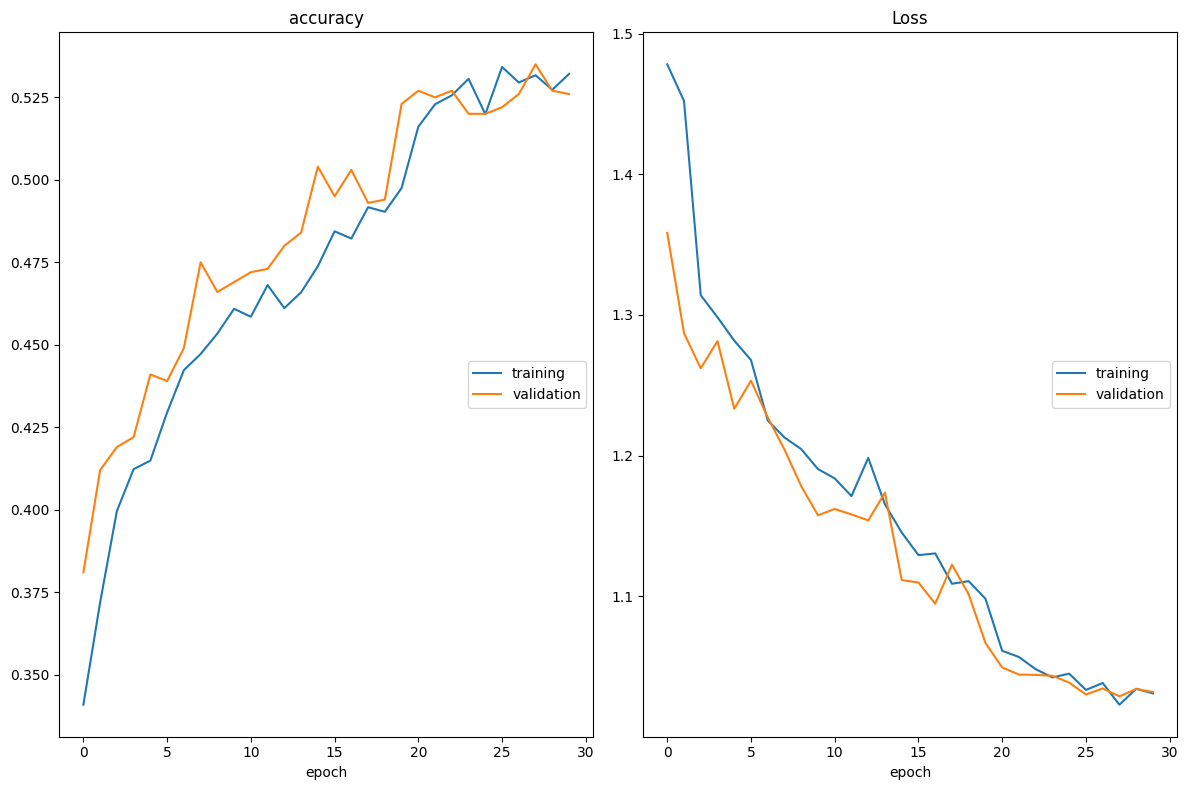

accuracy
	training         	 (min:    0.341, max:    0.534, cur:    0.532)
	validation       	 (min:    0.381, max:    0.535, cur:    0.526)
Loss
	training         	 (min:    1.023, max:    1.478, cur:    1.031)
	validation       	 (min:    1.029, max:    1.358, cur:    1.032)
Epoch 30/30: Train Loss = 1.0308, Train Acc = 0.5321, Val Loss = 1.0318, Val Acc = 0.5260


In [ ]:
# ============================================================
# Training loop with original + generated data
# ============================================================

from torch.utils.data import ConcatDataset
from collections import Counter

extra_annotations_file = "ShapesQA_trainset_extra/annotations.json"
extra_image_dir = "ShapesQA_trainset_extra"

if not os.path.exists(extra_annotations_file):
    raise FileNotFoundError("Run the previous cell first to generate extra data.")

with open(extra_annotations_file, "r") as f:
    extra_annotations = json.load(f)

print(f"Loaded extra samples: {len(extra_annotations)}")

# Optional: use fewer extra samples for quick debugging.
USE_EXTRA_LIMIT = None  # e.g., 2000 for quick tests
if USE_EXTRA_LIMIT is not None:
    extra_annotations = extra_annotations[:USE_EXTRA_LIMIT]

extra_subset_file = "ShapesQA_trainset_extra/annotations_subset.json"
with open(extra_subset_file, "w") as f:
    json.dump(extra_annotations, f, indent=2)

# Build vocab from original + extra questions.
merged_questions = [ann["question"] for ann in train_annotations] + [ann["question"] for ann in extra_annotations]
vocab_aug = build_vocab(merged_questions, min_freq=1)
print("Augmented vocabulary size:", len(vocab_aug))

orig_train_dataset = ShapesQADataset(
    annotations=train_annotations_file,
    image_dir=train_image_dir,
    vocab=vocab_aug,
    transform=train_image_transform,
    max_question_len=20,
)
extra_train_dataset = ShapesQADataset(
    annotations=extra_subset_file,
    image_dir=extra_image_dir,
    vocab=vocab_aug,
    transform=train_image_transform,
    max_question_len=20,
)

aug_train_dataset = ConcatDataset([orig_train_dataset, extra_train_dataset])
aug_val_dataset = ShapesQADataset(
    annotations=val_annotations_file,
    image_dir=val_image_dir,
    vocab=vocab_aug,
    transform=image_transform,
    max_question_len=20,
)

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
)
aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
)

# Base model architecture unchanged; train from scratch on augmented data.
num_answers = 15
model_aug = VQAModel(len(vocab_aug), num_answers=num_answers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_aug = optim.AdamW(filter(lambda p: p.requires_grad, model_aug.parameters()), lr=3e-4, weight_decay=1e-4)

num_epochs_aug = 30
freeze_epochs_aug = 18

model_aug = train_model(model_aug, optimizer_aug, aug_train_loader, aug_val_loader, num_epochs_aug, freeze_epochs_aug)


def evaluate_model(model_eval, data_loader):
    model_eval.eval()
    correct = 0
    total = 0
    type_correct = {}
    type_total = {}

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(device)
            questions = batch["question"].to(device)
            answers = batch["answer"].to(device)
            q_types = batch["question_type"]

            logits = model_eval(images, questions)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == answers).sum().item()
            total += answers.size(0)

            for i, qt in enumerate(q_types):
                if qt not in type_total:
                    type_total[qt] = 0
                    type_correct[qt] = 0
                type_total[qt] += 1
                if preds[i] == answers[i]:
                    type_correct[qt] += 1

    overall_acc = correct / max(1, total)
    return overall_acc, type_correct, type_total


overall_acc, type_correct, type_total = evaluate_model(model_aug, aug_val_loader)
print(f"\nAugmented training validation accuracy: {overall_acc:.4f} ({100*overall_acc:.2f}%)")

print("Validation accuracy by question type:")
for qt in sorted(type_total.keys()):
    acc = type_correct[qt] / max(1, type_total[qt])
    print(f"  {qt:10s}: {acc:.4f} ({type_correct[qt]}/{type_total[qt]})")

# Use this model for any downstream evaluation in this notebook section.
model = model_aug
val_loader = aug_val_loader
val_dataset = aug_val_dataset


#### **5. Revisiting Assignment 1: Zero-shot Image Classification with CLIP [3pts]**



In January 2021, OpenAI published a research paper named CLIP ([Contrastive Language-Image Pretraining](https://arxiv.org/abs/2103.00020)) https://openai.com/blog/clip/. This model was trained to maximize the dot product between vector representations of text and images that have a direct correspondence and minimize their dot product when they do not correspond. One key property of this model is that it can be used to build zero-shot classifier. Since the model was trained on a large number of images and text from the web, this model knows about a lot of categories of things. Your goal in this section is to obtain the best results using the illustrated approach in this figure for the scene classification problem of Assignment 1 (SUN20). You are not allowed to finetune or change anything in the model. Please enter the best classification accuracy in the [leaderboard](https://docs.google.com/spreadsheets/d/1LIhElAGCJBuZvPyQM-ZM_XMNjzffUVw9V8czHUy5GJ0/edit?usp=sharing) here using CLIP. [To get full points obtain more than 94% accuracy and your code should run in less than 60 seconds]. Feel free to use other versions of CLIP, e.g. MetaCLIP (https://github.com/facebookresearch/MetaCLIP), OpenCLIP (https://github.com/mlfoundations/open_clip), EVA-CLIP (https://github.com/baaivision/EVA).

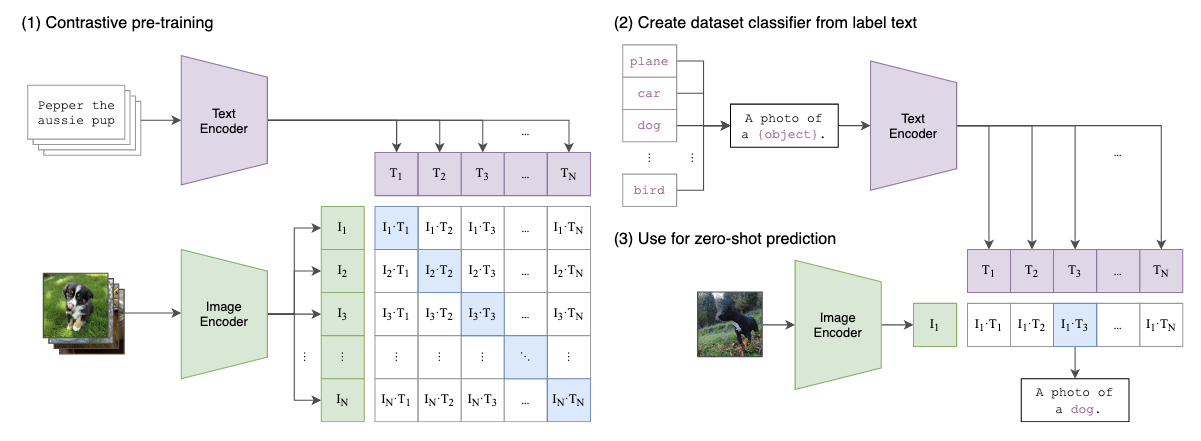

In [ ]:
# Zero-shot scene classification on SUN20 using CLIP.

import os
import time
import sys
import importlib.util
import subprocess
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

if importlib.util.find_spec("open_clip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "open_clip_torch"])

import open_clip


class SUN20ForCLIP(Dataset):
    def __init__(self, split="val", root="SUN20", transform=None):
        class_file = os.path.join(root, split, "ClassName.txt")
        classes = [line.strip() for line in open(class_file).read().splitlines() if line.strip()]
        self.classes = sorted(classes)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.transform = transform

        self.samples = []
        for c in self.classes:
            class_dir = os.path.join(root, split, c.lstrip("/"))
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                if os.path.isfile(fpath):
                    self.samples.append((fpath, self.class_to_idx[c]))

        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def category_to_text(category):
    return category.strip("/").replace("/", " ").replace("_", " ")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "ViT-L-14"
PRETRAIN = "openai"
BATCH_SIZE = 64

model_clip, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAIN, device=device)
model_clip.eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

sun20_val = SUN20ForCLIP(split="val", root="SUN20", transform=preprocess)
val_loader_clip = DataLoader(sun20_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"SUN20 val samples: {len(sun20_val)}")
print(f"SUN20 classes: {len(sun20_val.classes)}")

prompt_templates = [
    "a photo of a {}.",
    "a photo of the {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "a cropped photo of a {}.",
    "a close-up photo of a {}.",
    "a good photo of a {}.",
    "a blurry photo of a {}.",
]

with torch.no_grad():
    class_text_features = []
    for cls in sun20_val.classes:
        cls_text = category_to_text(cls)
        prompts = [tmpl.format(cls_text) for tmpl in prompt_templates]
        tokens = tokenizer(prompts).to(device)

        txt_feat = model_clip.encode_text(tokens)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat.mean(dim=0)
        txt_feat = txt_feat / txt_feat.norm()

        class_text_features.append(txt_feat)

    class_text_features = torch.stack(class_text_features, dim=0)  # (C, D)

start = time.time()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader_clip:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        img_feat = model_clip.encode_image(images)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        logits = (100.0 * img_feat @ class_text_features.T)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

elapsed = time.time() - start
acc = correct / max(1, total)

print(f"\nCLIP zero-shot val accuracy: {acc:.4f} ({100*acc:.2f}%)")
print(f"Evaluation time: {elapsed:.2f}s")


#### **6. Use Qwen2.5VL or Gemma3 to solve the ShapesQA problem [2pts -- extra]**

[QwenVL](https://huggingface.co/collections/Qwen/qwen25-vl) and [Gemma](https://huggingface.co/collections/google/gemma-3-release)  are powerful collections of Vision-Language-Models (VLMs). They are able to take input images and text and answer arbitrary questions. You can read more technical details about these models here https://arxiv.org/abs/2502.13923 and here https://arxiv.org/abs/2503.19786. Report the overall accuracy on the ShapesQA validation set using a  model from this family of models. You are required to use whichever version of these models that you can fit in the memory on Google Colab's GPU instances. Note: Finetuning or any type of training is not needed or allowed for this question. The model has to be used as-is. You only need to prompt it appropriately and compute the accuracy based on its answers. Enter your results here. https://docs.google.com/spreadsheets/d/13epOWzI6H-nFPmau9DKc3Vh5bWFiKSTiqiP21y9bS3U/edit?usp=sharing

In [ ]:
# Zero-shot ShapesQA with Qwen2.5-VL (no finetuning).
# Robust single-device inference path (avoids device_map/4bit hook shape issues).

import os
import re
import json

import torch
import transformers
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

print("transformers version:", transformers.__version__)

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
MAX_EVAL_SAMPLES = None  # set to e.g. 200 for quick tests

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# IMPORTANT: avoid device_map='auto' and 4-bit quantization here,
# because they can trigger shape-mismatch errors in some local stacks.
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    low_cpu_mem_usage=True,
    attn_implementation="eager",
)
model.to(device)
model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)

VALID_ANSWERS = [
    "red", "blue", "green", "yellow", "purple", "orange",
    "circle", "square", "triangle",
    "0", "1", "2", "3", "4", "5",
]
VALID_SET = set(VALID_ANSWERS)
WORD_TO_DIGIT = {
    "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5",
}


def normalize_answer(text):
    t = text.lower().strip()
    t = re.sub(r"[^a-z0-9 ]", " ", t)
    t = " ".join(t.split())

    tokens = [WORD_TO_DIGIT.get(tok, tok) for tok in t.split()]
    for tok in tokens:
        if tok in VALID_SET:
            return tok

    for ans in VALID_ANSWERS:
        if ans in t:
            return ans

    return "<unk>"


val_annotations = json.load(open("ShapesQA_valset/annotations.json"))
if MAX_EVAL_SAMPLES is not None:
    val_annotations = val_annotations[:MAX_EVAL_SAMPLES]

print(f"Evaluating {len(val_annotations)} validation samples with {MODEL_ID}")

instruction = (
    "Answer with exactly one token from this set: " + ", ".join(VALID_ANSWERS) + ". "
    "Do not output any explanation."
)

correct = 0
unknown = 0

for i, ann in enumerate(val_annotations):
    image_path = os.path.join("ShapesQA_valset", ann["image"])
    question = ann["question"]

    user_prompt = f"{instruction}\nQuestion: {question}\nAnswer:"

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": user_prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            use_cache=True,
        )

    new_tokens = output_ids[:, inputs["input_ids"].shape[-1]:]
    decoded = processor.batch_decode(new_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

    pred = normalize_answer(decoded)
    gt = str(ann["answer"]).strip().lower()

    if pred == "<unk>":
        unknown += 1
    if pred == gt:
        correct += 1

    if (i + 1) % 50 == 0:
        running_acc = correct / (i + 1)
        print(f"Processed {i+1}/{len(val_annotations)} | running acc={running_acc:.4f}")

final_acc = correct / max(1, len(val_annotations))
print(f"\nFinal ShapesQA zero-shot accuracy: {final_acc:.4f} ({100*final_acc:.2f}%)")
print(f"Unknown / unparsable outputs: {unknown}")


transformers version: 5.2.0


Loading weights: 100%|██████████| 824/824 [00:52<00:00, 15.75it/s, Materializing param=model.visual.patch_embed.proj.weight]                          


Evaluating 1000 validation samples with Qwen/Qwen2.5-VL-3B-Instruct


KeyboardInterrupt: 

: 